# Backtester Core Engine

**Owner:** James  
**Version:** 2.0 (Feb 13, 2026)  

Core backtesting engine for evaluating sports betting strategies.  
All logic is imported from `src/cuic_quant/backtest/backtester_backend.py`.  
See `docs/reference/strategy-interface.md` for the strategy function contract.

## Output Format

| Column | Type | Description |
|--------|------|-------------|
| timestamp | datetime | When trade happened |
| game | str | "Home vs Away" |
| action | str | 'BUY_HOME' or 'BUY_AWAY' |
| bet_size | float | Dollars bet |
| odds | float | Decimal odds used |
| outcome | str | 'WIN' or 'LOSS' |
| pnl | float | Profit/loss for this trade |
| cumulative_pnl | float | Running total P&L |
| bankroll | float | Current bankroll after trade |

In [ ]:
import sys
from pathlib import Path

# Ensure src/ is importable when running from tools/ directory
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from cuic_quant.backtest import (
    load_backtest_data,
    backtest,
    always_bet_away,
    validate_backtest_results,
    display_extended_metrics,
    plot_performance,
)

## Configuration

In [2]:
DATA_DIR = PROJECT_ROOT / "data"
DUMMY_CSV = DATA_DIR / "dummy_backtest_input.csv"
TEST_CSV = DATA_DIR / "test_games.csv"

## Load Data

In [3]:
data = load_backtest_data("2026-01-01", "2026-01-31", csv_path=DUMMY_CSV)
print(f"Games loaded: {len(data)}")
data.head()

Loaded 25 rows from dummy_backtest_input.csv.
Games loaded: 25


,timestamp,game,home_team,away_team,home_odds,away_odds,home_win
0,2026-01-01,Lakers vs Celtics,Lakers,Celtics,1.95,2.05,1
1,2026-01-02,Warriors vs Heat,Warriors,Heat,1.80,2.20,1
2,2026-01-03,Bucks vs Nets,Bucks,Nets,1.65,2.45,1
3,2026-01-04,Nuggets vs Suns,Nuggets,Suns,2.10,1.85,0
4,2026-01-05,76ers vs Knicks,76ers,Knicks,1.90,2.00,1


## Strategy

Using the built-in `always_bet_home` test strategy.

To use your own strategy, replace the assignment below:

```python
def my_strategy(row, context=None):
    return {"action": "BUY_HOME", "confidence": 0.8, "size": 50.0}

strategy = my_strategy
```

See `docs/reference/strategy-interface.md` for the full contract.

In [4]:
strategy = always_bet_away

## Run Backtest

In [5]:
results = backtest(data, strategy, initial_bankroll=10000.0)
print(f"Total trades: {len(results)}")
results

Total trades: 25


,timestamp,game,action,bet_size,odds,outcome,pnl,cumulative_pnl,bankroll
0,2026-01-01,Lakers vs Celtics,BUY_AWAY,100.0,2.05,LOSS,-100.0,-100.0,9900.0
1,2026-01-02,Warriors vs Heat,BUY_AWAY,100.0,2.20,LOSS,-100.0,-200.0,9800.0
2,2026-01-03,Bucks vs Nets,BUY_AWAY,100.0,2.45,LOSS,-100.0,-300.0,9700.0
3,2026-01-04,Nuggets vs Suns,BUY_AWAY,100.0,1.85,WIN,85.0,-215.0,9785.0
4,2026-01-05,76ers vs Knicks,BUY_AWAY,100.0,2.00,LOSS,-100.0,-315.0,9685.0
5,2026-01-06,Celtics vs Heat,BUY_AWAY,100.0,2.30,LOSS,-100.0,-415.0,9585.0
6,2026-01-07,Lakers vs Warriors,BUY_AWAY,100.0,1.78,WIN,78.0,-337.0,9663.0
7,2026-01-08,Nets vs Bucks,BUY_AWAY,100.0,1.60,WIN,60.0,-277.0,9723.0
8,2026-01-09,Suns vs 76ers,BUY_AWAY,100.0,2.00,LOSS,-100.0,-377.0,9623.0
9,2026-01-10,Knicks vs Nuggets,BUY_AWAY,100.0,1.72,WIN,72.0,-305.0,9695.0


## Summary Statistics

In [6]:
if len(results) > 0:
    wins = (results["outcome"] == "WIN").sum()
    losses = (results["outcome"] == "LOSS").sum()
    win_rate = wins / len(results)
    final_pnl = results["cumulative_pnl"].iloc[-1]
    final_bankroll = results["bankroll"].iloc[-1]

    print(f"Win Rate:        {win_rate:.1%} ({wins}W / {losses}L)")
    print(f"Total P&L:       ${final_pnl:,.2f}")
    print(f"Final Bankroll:  ${final_bankroll:,.2f}")
    print(f"ROI:             {final_pnl / 10000:.1%}")
else:
    print("No trades executed.")

Win Rate:        40.0% (10W / 15L)
Total P&L:       $-677.00
Final Bankroll:  $9,323.00
ROI:             -6.8%


## Validate Results

Run the full validation suite to check schema, math correctness, and data leakage.

The validator runs **11 checks** across three categories:

### 1. Schema Validation (5 checks)
- **Column names** — output has exactly the 9 required columns in the correct order.
- **Valid actions** — every action is `BUY_HOME` or `BUY_AWAY` (no `SKIP` rows in output).
- **Valid outcomes** — every outcome is `WIN` or `LOSS`.
- **Positive bet sizes** — no zero or negative bets.
- **Valid odds** — all decimal odds are > 1.0.

### 2. Math Correctness (4 checks)
- **PnL formula** — WIN trades pay `bet_size * (odds - 1)`, LOSS trades pay `-bet_size`.
- **Cumulative PnL** — the `cumulative_pnl` column is a correct running sum of `pnl`.
- **Bankroll tracking** — `bankroll = initial_bankroll + cumulative_pnl` at every row.
- **No overbetting** — no bet exceeds the bankroll available at the time of the bet.

### 3. Data Leakage Detection (2 checks)
- **Outcome consistency** — each trade's outcome is cross-referenced against the original input data's `home_win` column. If a strategy somehow produced outcomes that don't match the actual game results, this catches it (e.g., a bug that lets the strategy "see" the outcome before betting).
- **Chronological order** — trades must be in timestamp order. Out-of-order trades could indicate the strategy accessed future game data to make decisions.

> **Why leakage checks matter:** A backtester bug that leaks future information (e.g., passing `home_win` to the strategy) would produce unrealistically high win rates. These checks verify the backtester correctly strips outcome data before calling the strategy.

In [7]:
report = validate_backtest_results(results, data)

if report["passed"]:
    print(f"PASSED: {report['checks_passed']}/{report['checks_run']} checks passed")
else:
    print(f"FAILED: {report['checks_passed']}/{report['checks_run']} checks passed")
    for f in report["failures"]:
        print(f"  - {f}")

PASSED: 12/12 checks passed


## Performance Metrics

Extended metrics from Ben's `cuic_quant.metrics` module plus additional risk/reward statistics.

In [ ]:
display_extended_metrics(results)

## Performance Graphs

Cumulative P&L, drawdown, P&L distribution, and trade outcomes.

In [ ]:
plot_performance(results)

## Test with Mya's `test_games.csv`

Run the backtester against Mya's 100-row test dataset to validate compatibility.

Loaded 100 rows from test_games.csv.
Mya's data: 100 trades

Win Rate:        51.0% (51W / 49L)
Total P&L:       $320.70
Final Bankroll:  $10,320.70
ROI:             3.2%

Validation: PASSED
Checks: 12/12

       EXTENDED PERFORMANCE METRICS
  Sharpe Ratio:              0.488
  Sortino Ratio:             0.000
  Max Drawdown:             11.9%
  Profit Factor:             1.065
  Average Win:          $   102.37
  Average Loss:         $  -100.00
  Win/Loss Ratio:            1.024
  Expected Value/Bet:   $     3.21
  Longest Win Streak:            8
  Longest Loss Streak:           9
  Best Trade:           $   156.90
  Worst Trade:          $  -100.00


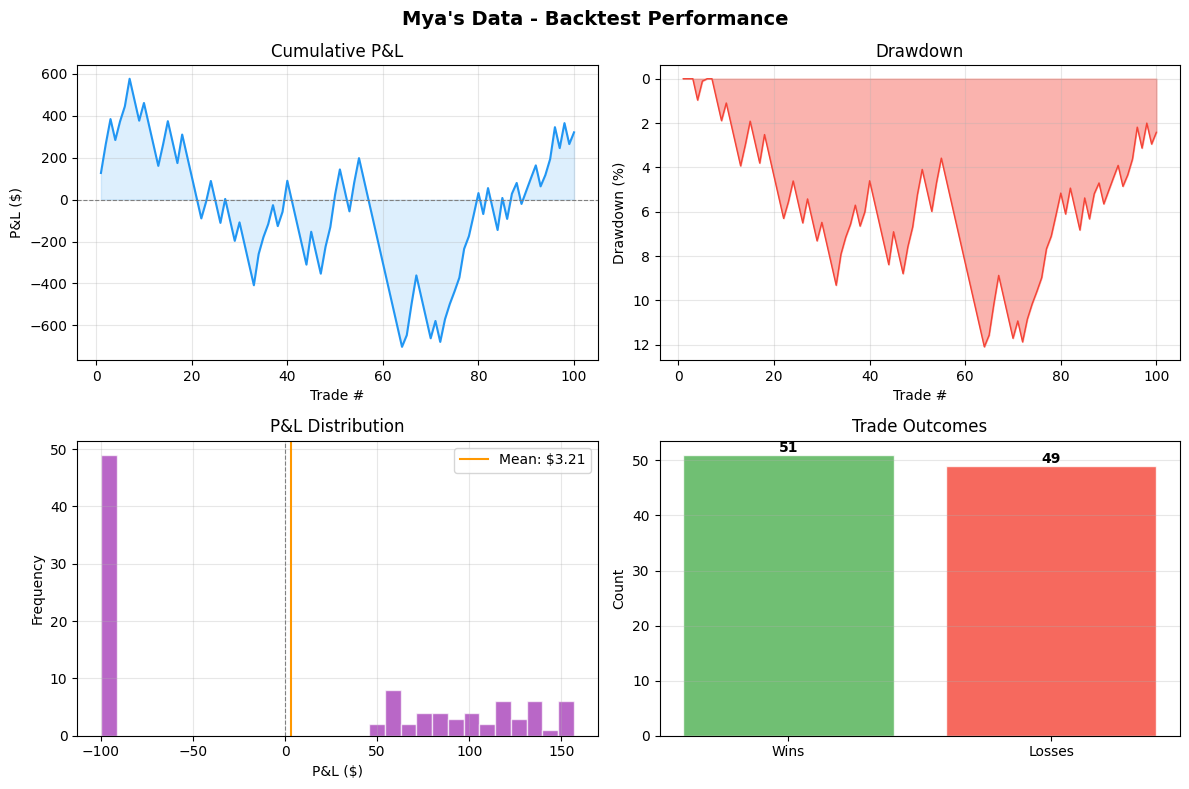

,timestamp,game,action,bet_size,odds,outcome,pnl,cumulative_pnl,bankroll
0,2026-01-01 00:00:00,Brooklyn Nets vs Phoenix Suns,BUY_AWAY,100.0,2.267,WIN,126.7,126.7,10126.7
1,2026-01-01 00:01:00,LA Clippers vs Miami Heat,BUY_AWAY,100.0,2.365,WIN,136.5,263.2,10263.2
2,2026-01-01 00:02:00,Portland Trail Blazers vs Los Angeles Lakers,BUY_AWAY,100.0,2.208,WIN,120.8,384.0,10384.0
3,2026-01-01 00:03:00,Milwaukee Bucks vs Houston Rockets,BUY_AWAY,100.0,2.208,LOSS,-100.0,284.0,10284.0
4,2026-01-01 00:04:00,Washington Wizards vs Portland Trail Blazers,BUY_AWAY,100.0,1.890,WIN,89.0,373.0,10373.0
...,...,...,...,...,...,...,...,...,...
95,2026-01-01 01:35:00,Denver Nuggets vs Minnesota Timberwolves,BUY_AWAY,100.0,2.521,WIN,152.1,345.4,10345.4
96,2026-01-01 01:36:00,Portland Trail Blazers vs Oklahoma City Thunder,BUY_AWAY,100.0,1.866,LOSS,-100.0,245.4,10245.4
97,2026-01-01 01:37:00,Portland Trail Blazers vs Oklahoma City Thunder,BUY_AWAY,100.0,2.193,WIN,119.3,364.7,10364.7
98,2026-01-01 01:38:00,Los Angeles Lakers vs Chicago Bulls,BUY_AWAY,100.0,2.380,LOSS,-100.0,264.7,10264.7


In [10]:
if TEST_CSV.exists():
    mya_data = load_backtest_data("2026-01-01", "2026-12-31", csv_path=TEST_CSV)
    mya_results = backtest(mya_data, strategy, initial_bankroll=10000.0)
    mya_report = validate_backtest_results(mya_results, mya_data)

    print(f"Mya's data: {len(mya_results)} trades\n")

    # Summary stats
    if len(mya_results) > 0:
        wins = (mya_results["outcome"] == "WIN").sum()
        losses = (mya_results["outcome"] == "LOSS").sum()
        win_rate = wins / len(mya_results)
        final_pnl = mya_results["cumulative_pnl"].iloc[-1]
        final_bankroll = mya_results["bankroll"].iloc[-1]

        print(f"Win Rate:        {win_rate:.1%} ({wins}W / {losses}L)")
        print(f"Total P&L:       ${final_pnl:,.2f}")
        print(f"Final Bankroll:  ${final_bankroll:,.2f}")
        print(f"ROI:             {final_pnl / 10000:.1%}\n")

    # Validation
    print(f"Validation: {'PASSED' if mya_report['passed'] else 'FAILED'}")
    print(f"Checks: {mya_report['checks_passed']}/{mya_report['checks_run']}")
    if not mya_report["passed"]:
        print("\nFailed checks:")
        for f in mya_report["failures"]:
            print(f"  - {f}")

    # Extended metrics & graphs
    print()
    display_extended_metrics(mya_results)
    plot_performance(mya_results, title="Mya's Data - Backtest Performance")

    # Display results table
    display(mya_results)
else:
    print(f"test_games.csv not found at {TEST_CSV}")